In [92]:
import sys
import os

# Remove cached modules
if 'utils.lab_utils' in sys.modules:
    del sys.modules['utils.lab_utils']
if 'utils' in sys.modules:
    del sys.modules['utils']

import cv2
import matplotlib.pyplot as plt
import numpy as np


In [93]:
from skimage.color import rgb2hsv
from utils.lab_utils import apply_hsv_threshold, apply_rgb_threshold

from utils.lab_utils import extract_rgb_channels, extract_hsv_channels
from utils.lab_01_utils import plot_colors_histo

In [94]:
# Take a card and segment it from the background

img_path = "data/bonus_images/cropped/bonus_6.jpg"

# show the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = rgb2hsv(img_rgb)

Input image shape: 443x615 with 3 channels


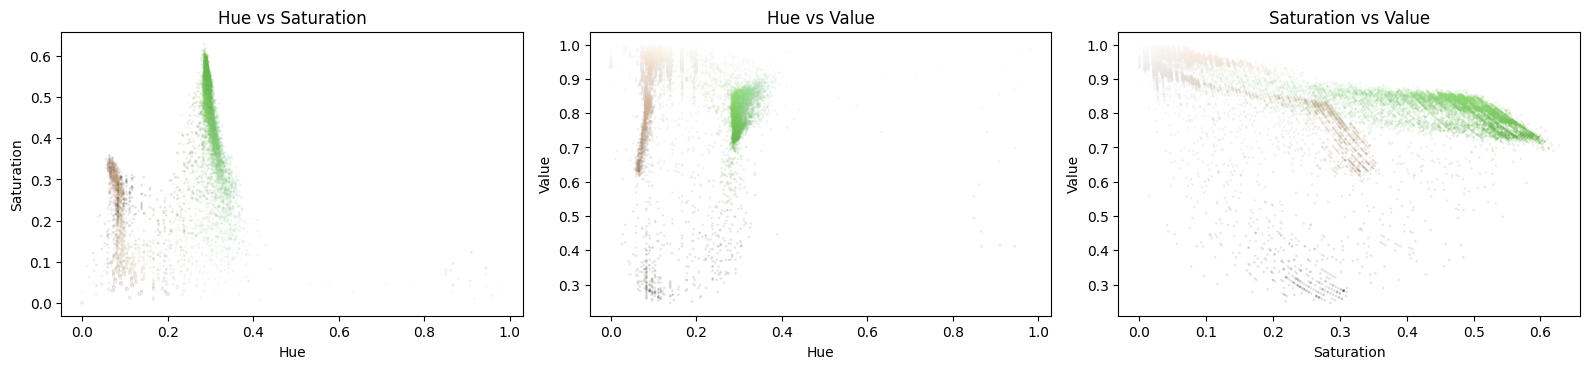

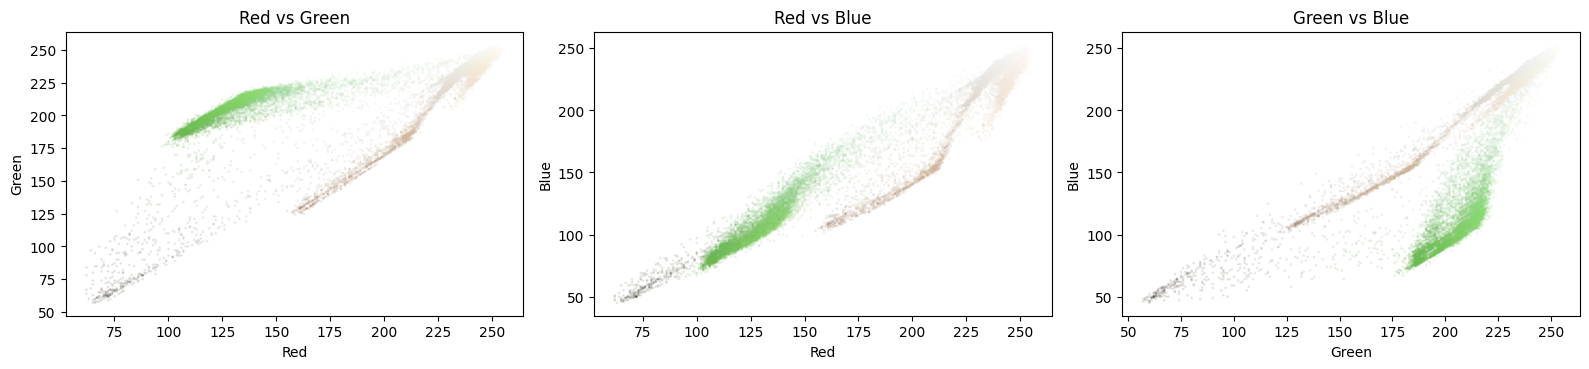

In [95]:
plot_colors_histo(img_rgb, func=extract_hsv_channels, labels=["Hue", "Saturation", "Value"])
plot_colors_histo(img_rgb, func=extract_rgb_channels, labels=["Red", "Green", "Blue"])

In [96]:
def get_card_colour(img: np.ndarray, plot: bool = False) -> str:
    """
    Classify the color of a card based on its image.

    Args
    img: np.ndarray (M, N, C)

    Returns
    str: y, r, b, g, or k
    """
    
    yellow_mask = apply_hsv_threshold(img, h_min=0.1, h_max=0.2, s_min=0.4, v_min=0.5)
    green_mask = apply_hsv_threshold(img, h_min=0.2, h_max=0.4, s_min=0.4, v_min=0.5)
    blue_mask = apply_hsv_threshold(img, h_min=0.4, h_max=0.6, s_min=0.4, v_min=0.5)
    red_mask = apply_hsv_threshold(img, h_min=0.95, h_max=0.05, s_min=0.4, v_min=0.5)

    # show the masks and number of pixels in each mask
    if plot:
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        axs[0].imshow(yellow_mask, cmap='gray')
        axs[0].set_title("Yellow Mask")
        axs[0].set_xlabel(f"Pixels: {np.sum(yellow_mask)}")

        axs[1].imshow(green_mask, cmap='gray')
        axs[1].set_title("Green Mask")
        axs[1].set_xlabel(f"Pixels: {np.sum(green_mask)}")

        axs[2].imshow(blue_mask, cmap='gray')
        axs[2].set_title("Blue Mask")
        axs[2].set_xlabel(f"Pixels: {np.sum(blue_mask)}")

        axs[3].imshow(red_mask, cmap='gray')
        axs[3].set_title("Red Mask")
        axs[3].set_xlabel(f"Pixels: {np.sum(red_mask)}")

        plt.show()

    # return the mask with number of pixels above a certain percentage of the total number of pixels in the image
    percentage_threshold = 0.2
    masks = [yellow_mask, green_mask, blue_mask, red_mask]
    colors = ['y', 'g', 'b', 'r']
    card_color = 'k'
    for mask, color in zip(masks, colors):
        if np.sum(mask) > percentage_threshold * img.shape[0] * img.shape[1]:
            card_color = color
            break
    return card_color

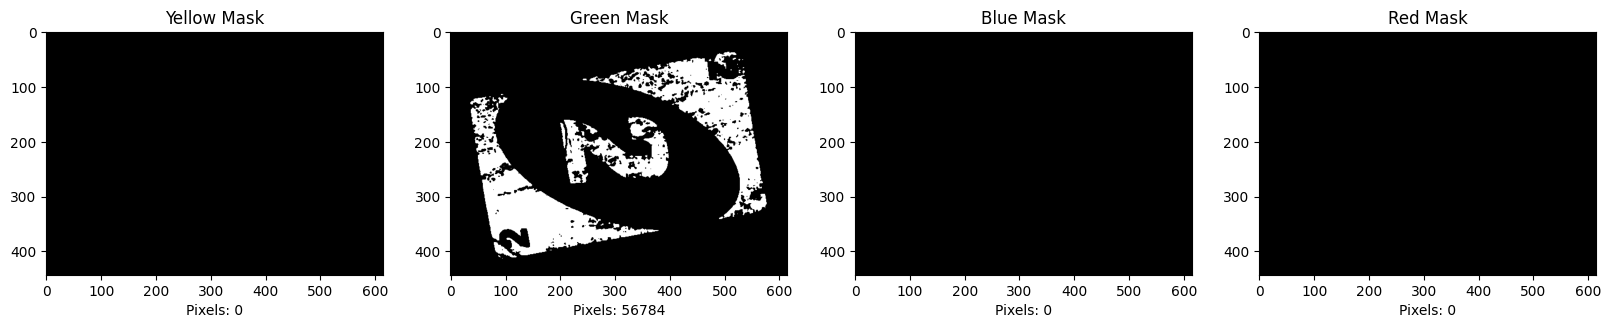

Card color: g


In [97]:
card_colour = get_card_colour(img_rgb, plot=True)
print("Card color:", card_colour)

In [98]:
def apply_colour_threshold(img_rgb: np.ndarray, color: str) -> np.ndarray:
    """
    Apply a threshold to the input image in rgb colorspace to extract objects of a specific color.

    """
    if color == 'b':
        img_th = apply_hsv_threshold(img_rgb, v_min = 0.75, s_min = 0.4, h_min=0.4, h_max=0.6)
    elif color == 'r':
        img_th = apply_hsv_threshold(img_rgb, v_min = 0.75, s_min = 0.5, h_min=0.97, h_max=0.05)
    elif color == 'y':
        img_th = apply_hsv_threshold(img_rgb, v_min = 0.75, s_min = 0.5, h_min=0.1, h_max=0.2)
    elif color == 'g':
        img_th = apply_hsv_threshold(img_rgb, h_min=0.2, h_max=0.4)
    elif color == 'k':
        img_th = apply_hsv_threshold(img_rgb, s_min = 0.4)
    else:
        raise ValueError("Color must be one of 'r', 'g', 'b', or 'y', 'k'")
    return img_th

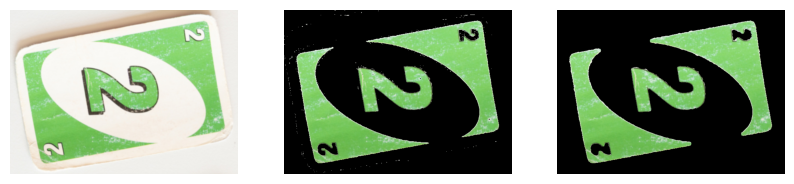

In [99]:

# apply a threshold to the image
img_thresholded = apply_colour_threshold(img_rgb, color=card_colour)

# plot the mask and the thresholded image side by side
plt.figure(figsize=(10, 5))

# mask
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.axis("off")

# threshold image
plt.subplot(1, 3, 2)
plt.imshow(img_rgb * img_thresholded[..., None])
plt.axis("off")

# fill holes in the mask

from utils.lab_utils import remove_holes, apply_closing, apply_opening

disk_size = 2
if get_card_colour == 'k':
    disk_size = 3
img_thresholded_filled = apply_closing(img_thresholded, disk_size=disk_size)
img_thresholded_filled = apply_opening(img_thresholded_filled, disk_size=5)

# threshold image

img_th = img_rgb * img_thresholded_filled[..., None]
plt.subplot(1, 3, 3)
plt.imshow(img_th)
plt.axis("off")

plt.show()

In [100]:
# Get the contour of the card and show all contours on the original image, including hole contours

from utils.lab_utils import find_contours

def find_contours_in_image(img_thresholded: np.ndarray, plot_contours=False):

    # Use the unfilled mask so internal holes are still present as contours.
    contours = find_contours(img_thresholded, n=11)[0]

    if plot_contours:
        # display all contours on a blank image
        img_contour = np.zeros_like(img_thresholded, dtype=np.uint8)
        cv2.drawContours(img_contour, contours, -1, (256,256,256), 2)

        plt.figure(figsize=(8, 8))
        plt.imshow(img_contour)
        plt.axis("off")
        plt.title(f"Contours found, including holes: {len(contours)}")
        plt.show()

    return contours

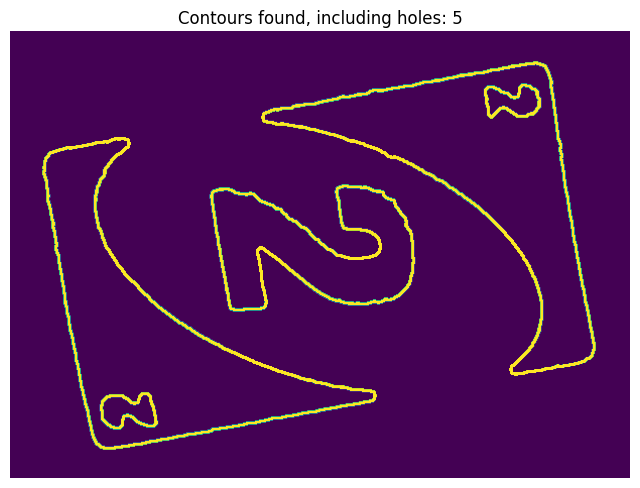

In [101]:
img_contours = find_contours_in_image(img_thresholded_filled, plot_contours=True)


In [ ]:
def get_card_value(img_contours: np.ndarray) -> str:
    """
    use the contours to classify the shape of the card.
    the classification should be translation and rotation invariant.
    compare to a set of template contours for each card value and color, and return the closest match.
    the template contours are in data/reference_images/contours/, 
    with the filename format "color_value_contours.png", e.g. "r_5_contours.png".
    the colour does not matter for shape classification, 
    only the color is used for the color classification step above

    Args
    img_contours: np.ndarray (M, N) or list of contours

    Returns
    str: 0, ..., 9, skip, reverse, draw_2, draw_4, or wild
    """

    card_value = "?"
    try:
        import glob
        templates_dir = os.path.join("data/reference_images/contours")
        pattern = os.path.join(templates_dir, "*_contours.png")
        template_files = sorted(glob.glob(pattern))
        if not template_files:
            return card_value

        # Normalize input contours to an iterable list
        input_contours = img_contours
        if isinstance(input_contours, np.ndarray):
            input_contours = list(input_contours)

        best_score = float('inf')
        best_value = card_value

        for tf in template_files:
            base = os.path.basename(tf)
            # label is the filename without the _contours.png suffix
            if base.lower().endswith('_contours.png'):
                label = base[:-len('_contours.png')]
            else:
                label = os.path.splitext(base)[0]

            # read the template contour image (expected white on black)
            tmpl = cv2.imread(tf, cv2.IMREAD_GRAYSCALE)
            if tmpl is None:
                continue
            _, thr = cv2.threshold(tmpl, 127, 255, cv2.THRESH_BINARY)
            contours_t, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            if not contours_t:
                continue
            tmpl_cnt = max(contours_t, key=cv2.contourArea)

            # compare template contour to each input contour and take best match
            for cnt in input_contours:
                try:
                    score = cv2.matchShapes(tmpl_cnt, cnt, cv2.CONTOURS_MATCH_I1, 0.0)
                except Exception:
                    continue
                if score < best_score:
                    best_score = score
                    # if the template filename encodes a color (e.g. r_5), strip it
                    parts = label.split('_', 1)
                    if len(parts) == 2 and parts[0] in ('r', 'g', 'b', 'y'):
                        best_value = parts[1]
                    else:
                        best_value = label

        # threshold for accepting a match (lower is better). If no good match found, return '?'
        if best_score < 0.20:
            card_value = best_value
        else:
            card_value = '?'
    except Exception:
        # keep default on error
        pass

    return card_value


In [126]:
def process_card_image(cropped_path: str, verb: bool = False) -> None:
    """
    Process the input image of a card to extract the card from the background.

    Final directory structure:
    ```
    parent_dir/
    ├── cropped/
    ├── thresholded/
    ├── mask/
    └── contours/
    ```

    Files:
    - The thresholded image to ../thresholded with the same filename ending in _th
    - The mask to ../mask with the same filename ending in _mask
    - The contours to ../contours with the same filename ending in _contours

    Args
    cropped_path: str: Path to the cropped image file.

    Returns
    None
    """

    # cropped directory is the directory of the cropped image 
    cropped_dir = os.path.dirname(cropped_path)
    # parent_dir is one level up from the cropped directory
    parent_dir = os.path.dirname(cropped_dir)
    if verb: print("Parent directory:", parent_dir)
    
    threshold_dir = os.path.join(parent_dir, "thresholded")
    mask_dir = os.path.join(parent_dir, "mask")
    contours_dir = os.path.join(parent_dir, "contours")

    # Create output directories if they don't exist
    os.makedirs(threshold_dir, exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)
    os.makedirs(contours_dir, exist_ok=True)

    img_bgr = cv2.imread(cropped_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Use a smaller preview for color classification to reduce runtime.
    preview_rgb = cv2.resize(img_rgb, None, fx=0.35, fy=0.35, interpolation=cv2.INTER_AREA)
    card_colour = get_card_colour(preview_rgb)

    img_thresholded = apply_colour_threshold(img_rgb, color=card_colour)

    disk_size = 3 if card_colour == 'k' else 5.5
    img_thresholded_filled = apply_closing(img_thresholded, disk_size=disk_size)

    # Keep image in uint8 range [0, 255] without re-scaling overflow.
    img_result_rgb = (img_rgb * img_thresholded_filled[..., None]).astype(np.uint8)

    # OpenCV writes BGR, so convert from RGB before saving.
    img_result_bgr = cv2.cvtColor(img_result_rgb, cv2.COLOR_RGB2BGR)

    # Save the thresholded image with _th suffix
    threshold_path = os.path.join(threshold_dir, os.path.splitext(os.path.basename(cropped_path))[0] + "_th.png")
    if verb: print("\tSaving thresholded image to:", threshold_path)
    cv2.imwrite(threshold_path, img_result_bgr)

    # Save the mask with _mask suffix
    mask_path = os.path.join(mask_dir, os.path.splitext(os.path.basename(cropped_path))[0] + "_mask.png")
    if verb: print("\tSaving mask to:", mask_path)
    cv2.imwrite(mask_path, img_thresholded_filled.astype(np.uint8) * 255)

    # compute the contours
    contours = find_contours(img_thresholded_filled, n=11)[0]
    # save the contours with _contours suffix as a white line on blank image
    contour_img = np.zeros_like(img_thresholded_filled, dtype=np.uint8)
    cv2.drawContours(contour_img, contours, -1, (256,256,256), 2)
    contours_path = os.path.join(contours_dir, os.path.splitext(os.path.basename(cropped_path))[0] + "_contours.png")
    if verb: print("\tSaving contours to:", contours_path)
    cv2.imwrite(contours_path, contour_img)
    
    return

In [ ]:
def classify_card(img_rgb: np.ndarray) -> str:
    """
    Classify the color of a card based on its image.

    Args
    img: np.ndarray (M, N, C)

    Returns
    str: value of the card, including color and shape, 
    e.g. "r_5", "g_skip", "y_draw_2", "wild", or "draw_4"
    """
    
    card_colour = get_card_colour(img_rgb)
    print("Card color:", card_colour)

    img_thresholded = apply_colour_threshold(img_rgb, color=card_colour)

    disk_size = 5.5 if card_colour != 'k' else 3
    img_thresholded_filled = apply_closing(img_thresholded, disk_size=disk_size)
    img_thresholded_filled = apply_opening(img_thresholded_filled, disk_size=5)

    # Keep image in uint8 range [0, 255] without re-scaling overflow.
    img_result_rgb = (img_rgb * img_thresholded_filled[..., None]).astype(np.uint8)

    # Get the contour of the card
    img_contours = find_contours_in_image(img_thresholded_filled, plot_contours=False)

    card_value = get_card_value(img_contours)

    # return the color and shape as a string
    if card_value == 'wild':
        return "wild"
    elif card_value == 'draw_4':
        return "draw_4"
    else:
        return f"{card_colour}_{card_value}"

## Testing

testing out the classification on a of bonus_images

In [133]:
bonus_img_paths = [f"data/bonus_images/cropped/bonus_{i}.jpg" for i in range(1, 6)]

for bonus_img_path in bonus_img_paths:
    img_bgr = cv2.imread(bonus_img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    card_value = classify_card(img_rgb)
    print("Card value:", card_value)

Card color: b
Card value: b_1
Card color: y
Card value: y_1
Card color: r
Card value: r_1
Card color: r
Card value: r_2
Card color: y
Card value: y_7


## Pipelines

### Reference Images

These are images cropped from reference images.
Their filename is the value they have, e.g. 'r_4', 'b_skip', 'draw_4'

In [122]:
# iterate through cards in data/reference_images/cropped

input_dir = "data/reference_images/cropped"

output_dir = "data/reference_images"
os.makedirs(output_dir, exist_ok=True)

threshold_dir = os.path.join(output_dir, "thresholded")
os.makedirs(threshold_dir, exist_ok=True)

mask_dir = os.path.join(output_dir, "mask")
os.makedirs(mask_dir, exist_ok=True)

contour_dir = os.path.join(output_dir, "contours")
os.makedirs(contour_dir, exist_ok=True)


valid_ext = (".jpg", ".jpeg", ".png")
filenames = sorted(
    f for f in os.listdir(input_dir)
    if f.lower().endswith(valid_ext) and not f.lower().endswith("_th.png")
)

for filename in filenames:
    img_path = os.path.join(input_dir, filename)

    process_card_image(img_path)

print(f"Saved {len(filenames)} thresholded images to {output_dir}")

Saved 54 thresholded images to data/reference_images


In [123]:
# iterate through cards in data/bonus_images/cropped

input_dir = "data/bonus_images/cropped"

output_dir = "data/bonus_images"
os.makedirs(output_dir, exist_ok=True)

threshold_dir = os.path.join(output_dir, "thresholded")
os.makedirs(threshold_dir, exist_ok=True)

mask_dir = os.path.join(output_dir, "mask")
os.makedirs(mask_dir, exist_ok=True)

contour_dir = os.path.join(output_dir, "contours")
os.makedirs(contour_dir, exist_ok=True)


valid_ext = (".jpg", ".jpeg", ".png")
filenames = sorted(
    f for f in os.listdir(input_dir)
    if f.lower().endswith(valid_ext) and not f.lower().endswith("_th.png")
)

for filename in filenames:
    img_path = os.path.join(input_dir, filename)
    process_card_image(img_path, verb=True)


print(f"Saved {len(filenames)} thresholded images to {output_dir}")

Parent directory: data/bonus_images
	Saving thresholded image to: data/bonus_images/thresholded/bonus_1_th.png
	Saving mask to: data/bonus_images/mask/bonus_1_mask.png
	Saving contours to: data/bonus_images/contours/bonus_1_contours.png
Parent directory: data/bonus_images
	Saving thresholded image to: data/bonus_images/thresholded/bonus_2_th.png
	Saving mask to: data/bonus_images/mask/bonus_2_mask.png
	Saving contours to: data/bonus_images/contours/bonus_2_contours.png
Parent directory: data/bonus_images
	Saving thresholded image to: data/bonus_images/thresholded/bonus_3_th.png
	Saving mask to: data/bonus_images/mask/bonus_3_mask.png
	Saving contours to: data/bonus_images/contours/bonus_3_contours.png
Parent directory: data/bonus_images
	Saving thresholded image to: data/bonus_images/thresholded/bonus_4_th.png
	Saving mask to: data/bonus_images/mask/bonus_4_mask.png
	Saving contours to: data/bonus_images/contours/bonus_4_contours.png
Parent directory: data/bonus_images
	Saving threshol

In [106]:
noisy_scene_test_path = "data/test_images/L1000957.jpg"

# do hsv thresholding on the test image and show the result
""" noisy_scene_test = cv2.imread(noisy_scene_test_path)
noisy_scene_test_rgb = cv2.cvtColor(noisy_scene_test, cv2.COLOR_BGR2RGB)   

plot_colors_histo(noisy_scene_test_rgb, func=extract_hsv_channels, labels=["Hue", "Saturation", "Value"])

test_thresholded = apply_hsv_threshold(noisy_scene_test_rgb, h_min=0.97, h_max=0.05, s_min=0.7)

# plot the mask and the thresholded image side by side
plt.figure(figsize=(10, 5))
# mask
plt.subplot(1, 2, 1)
plt.imshow(test_thresholded)
plt.axis("off")
# threshold image
plt.subplot(1, 2, 2)
plt.imshow(noisy_scene_test_rgb * test_thresholded[..., None])
plt.axis("off") """

' noisy_scene_test = cv2.imread(noisy_scene_test_path)\nnoisy_scene_test_rgb = cv2.cvtColor(noisy_scene_test, cv2.COLOR_BGR2RGB)   \n\nplot_colors_histo(noisy_scene_test_rgb, func=extract_hsv_channels, labels=["Hue", "Saturation", "Value"])\n\ntest_thresholded = apply_hsv_threshold(noisy_scene_test_rgb, h_min=0.97, h_max=0.05, s_min=0.7)\n\n# plot the mask and the thresholded image side by side\nplt.figure(figsize=(10, 5))\n# mask\nplt.subplot(1, 2, 1)\nplt.imshow(test_thresholded)\nplt.axis("off")\n# threshold image\nplt.subplot(1, 2, 2)\nplt.imshow(noisy_scene_test_rgb * test_thresholded[..., None])\nplt.axis("off") '

In [107]:
# testing the function on the test image